# EXAMEN PRIMER PARCIAL

## EJERCICIO 1

Utilizando los datos del archivo Ejercicio1.csv, realice un modelo de regresión
lineal. Para su modelo, utilice la implementación de regresión de la biblioteca de sklearn.
Calcule las métricas de rendimiento: Error cuadrático medio y el Error absoluto medio.
Hint: Recuerde que los modelos de regresión piden X como un arreglo de arreglos, use la
línea: X.reshape(-1, 1) para crear su vector de vectores

In [57]:
#Librerias 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt 

In [58]:
#Cargar Datos
df1 = pd.read_csv("Ejercicio1.csv")
X = df1["X"].values
y = df1["y"].values

In [59]:
X = X.reshape(-1,1)
model = LinearRegression()
model.fit(X,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = model.predict(X)


In [61]:
print(f"El error absoluto medio es {mean_absolute_error(y,y_pred)}")

print(f"El error cuadrático medio es {mean_squared_error(y,y_pred)}")

El error absoluto medio es 5.874547795401409
El error cuadrático medio es 54.915751588684934


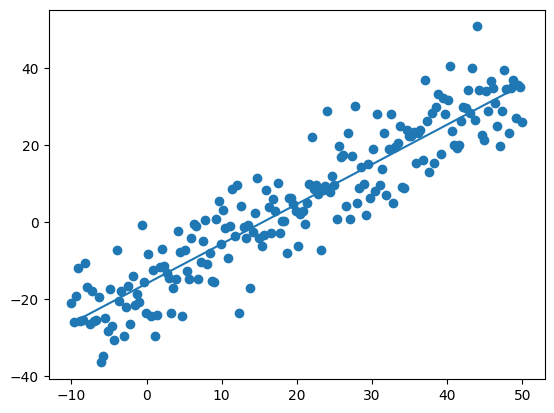

In [62]:
#Graficar 
plt.scatter(X,y)
plt.plot(X,y_pred)
plt.show()

## Ejercicio 2

Utilizando los mismos datos del ejercicio anterior (Ejercicio1.csv), implemente
el descenso del gradiente sin uso de la biblioteca de sklearn, vaya almacenando en una
lista o vector los valores de pérdida: loss para que pueda graficar la función de pérdida o
costo a lo largo de las épocas.

Realice las gráficas del modelo y la función de pérdida, calcule el Error cuadrático medio
y el Error absoluto medio. Hint: Recuerde que la matriz X en su primera columna es una
columna de unos, ya que esa columna nos ayuda a calcular la intersección, use la función
numpy.c_[np.ones(X.shape[0]), X] para crear esa matriz. Recuerde que:

Intercepto: [-5.5652621]
Pendiente: [0.73523574]
MSE: 101.25696036435623
MAE: 8.10723800452607


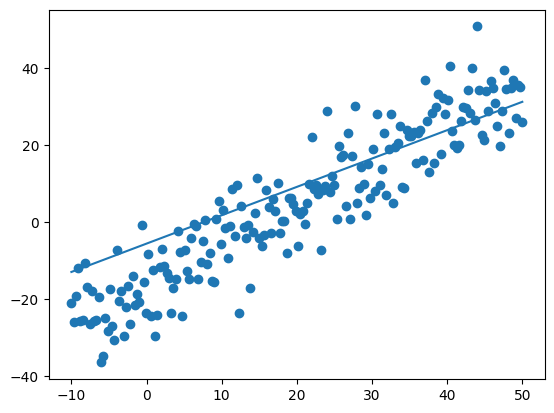

In [115]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = pd.read_csv("Ejercicio1.csv")

X_raw= data["X"].values.reshape(-1,1)
y = data["y"].values.reshape(-1,1)

m = len(y)

X = np.hstack((np.ones((m,1)), X_raw))

w = np.zeros((2,1))   
epocas = 10000
alpha = 0.0001
loss = []

for _ in range(epocas):
    y_pred = X @ w
    error = y_pred - y
    cost = (1/(2*m)) * np.sum(error**2)
    loss.append(cost)
    grad = (1/m) * (X.T @ error)
    w = w - alpha * grad

y_pred = X @ w

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("Intercepto:", w[0])
print("Pendiente:", w[1])
print("MSE:", mse)
print("MAE:", mae)

#Graficar 
plt.scatter(X_raw,y)
plt.plot(X_raw,y_pred)
plt.show()


## EJERCICIO 3

 Utilizando los datos del archivo Ejercicio3.csv, realice un modelo de regresión
lineal polinomial de grado 3. Para su modelo, utilice la implementación de regresión de
la biblioteca de sklearn. Calcule las métricas de rendimiento: Error cuadrático medio y
el Error absoluto medio. Hint: Recuerde que debe construir su matriz de características
polinomiales, para ello use sklearn.preprocessing.PolynomialFeatures

In [64]:
#Librerias
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures


In [65]:
#cargar datos
df3 = pd.read_csv("Ejercicio3.csv")
X_raw = df3["X"].values
y = df3["y"].values

X_raw = X_raw.reshape(-1,1)


In [66]:
poly = PolynomialFeatures(3)
X = poly.fit_transform(X_raw)
model = LinearRegression()
model.fit(X,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred = model.predict(X)

In [68]:
print(f"El error absoluto medio es {mean_absolute_error(y,y_pred)}")

print(f"El error cuadrático medio es {mean_squared_error(y,y_pred)}")

El error absoluto medio es 0.2848637069389076
El error cuadrático medio es 0.13921987087556156


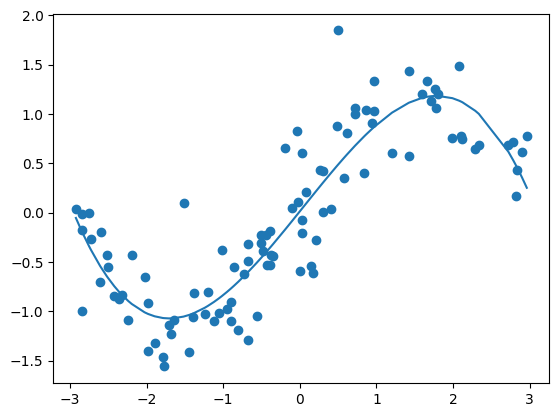

In [69]:
#Graficar
plt.scatter(X_raw,y)
plt.plot(X_raw,y_pred)

## EJERCICIO 4

. (2.0 pts) Utilizando los datos del archivo Ejercicio4.csv. Se realizó un experimento pa
ra determinar si era posible predecir el peso de un animal (y) después de un periodo
determinado con base en su peso inicial (X1) y la cantidad de alimento que consumía
(X2). Construya un modelo de regresión lineal múltiple utilizando la implementación de
sklearn o la propia para predecir el peso del animal. Grafique los datos en 3d y construya
su plano de regresión. Calcule el Error cuadrático medio y el Error absoluto medio. Hint:
Debe utilizar la biblioteca from mpl_toolkits.mplot3d import Axes3D.

In [108]:
import numpy as np 
from mpl_toolkits.mplot3d import Axes3D

data = pd.read_csv("Ejercicio4.csv")

X = data[["X1", "X2"]].values
y = data["y"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)
print("MSE:", mse)
print("MAE:", mae)



Intercepto: -17.89305201372207
Coeficientes: [1.37439485 0.20086605]
MSE: 22.775923985399707
MAE: 3.8135670937112924


## EJERCICIO 5
Utilizando los datos del archivo Ejercicio5.csv, realice un modelo de regresión
logística para realizar la clasificación. Para ello puede usar la implementación de sklearn,
además construya la matriz de confusión y calcule la sensibilidad, especificidad y exactitud
de su modelo. Hint: Para hacer la matriz de confusión, use: from sklearn.metrics import
confusion_matrix, ConfusionMatrixDisplay, y para las fronteras de decisión debe usar las
funciones.

In [101]:
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, accuracy_score

df5 = pd.read_csv("Ejercicio5.csv")
X = df5[["X1","X2"]].values
y = df5["y"].values

model = LogisticRegression()
model.fit(X,y)

y_pred = model.predict(X)

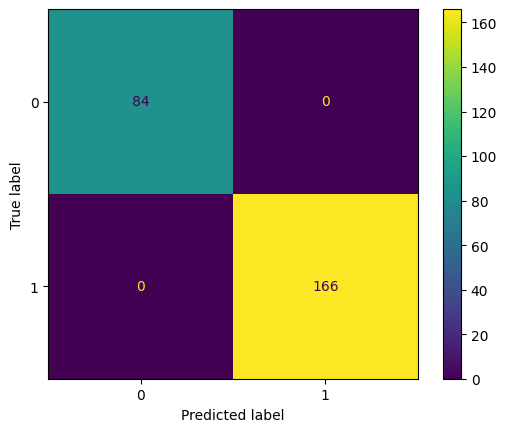

In [102]:
cm = confusion_matrix(y,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
recall = recall_score(y,y_pred)
print(f"El recall es de {recall}")

accuracy = accuracy_score(y,y_pred)
print(f"El accuracy score es de {accuracy}")

sensibilidad = recall_score(y_pred,y)
print(f"La sensibilidad es de {sensibilidad}") 

El recall es de 1.0
El accuracy score es de 1.0
La sensibilidad es de 1.0
